# Template Based Diagram Layouts
This notebook is intended to explore the use of template-based diagram layouts 
for visualizing relationships between structures in a dataset. 
The goal is to compare this approach with the current optimization-based layout 
and also to evaluate the use to Networkx for layouts.

## Setup

### Imports

In [1]:
from typing import Dict, List, Union

from pathlib import Path
import re

from pprint import pprint

In [2]:
import xml.etree.ElementTree as ET
from itertools import chain


In [3]:
import pandas as pd
import xlwings as xw
import networkx as nx
from matplotlib import pyplot as plt

In [4]:
from structure_set import StructureSet
from dicom import DicomStructureFile
from structure_id_parser import parse_structure_metadata, merge_priority_columns

INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: maximum_margin (MaximumMarginCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Paths

In [5]:
base_path = Path.cwd()
dicom_path = base_path / "tests"
structure_filter_def = base_path / "src" / "webapp" / "config" / "structure_filter_rules.json"

## Utility Functions

### Load the DICOM file

In [6]:
def load_structures(dicom_file: DicomStructureFile,
                    apply_filter=False)->pd.DataFrame:
    '''
    Load structure names from a DICOM file and optionally apply a filter.

    Args:
        dicom_file (DicomStructureFile): The DICOM structure file.
        apply_filter (bool): Whether to apply a filter to the structures.
            Default is False.

    Returns:
        pd.DataFrame: A DataFrame containing the structure IDs and their metadata.
    '''
    # get structure IDs
    meta_data = dicom_file.get_structure_filter_metadata()
    if apply_filter:
        filter_report = dicom_file.evaluate_structure_filters(structure_filter_def)
        selection = filter_report.SelectedByDefault & filter_report.DisplayedByDefault
        meta_data = meta_data[selection]
    return meta_data

## Load an example CNS DICOM structure set

### Path to the example DICOM file

In [7]:
dcm_file_name = 'RS.CNS_FSRT_2_GTV.BRAI.dcm'
dcm_file_path = dicom_path / dcm_file_name
dicom_file = DicomStructureFile(top_dir=dicom_path, file_path=dcm_file_path)
pprint(dicom_file.structure_set_info)


INFO:dicom:Successfully loaded DICOM dataset from RS.CNS_FSRT_2_GTV.BRAI.dcm
INFO:dicom:Extracted 2911 contours from 35 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.CNS_FSRT_2_GTV.BRAI.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.040 cm/pixel


{'File': WindowsPath("d:/OneDrive - Queen's University/Python/Projects/StructureRelations/tests/RS.CNS_FSRT_2_GTV.BRAI.dcm"),
 'PatientID': 'CNS_FSRT_2_GTV',
 'PatientLastName': 'CNS_FSRT_2_GTV_Partition_Error',
 'PatientName': 'CNS_FSRT_2_GTV_Partition_Error',
 'SeriesDescription': '',
 'SeriesNumber': '0',
 'StructureSet': 'BRAI',
 'StudyID': ''}


In [8]:
structure_data = load_structures(dicom_file)
structures_df = parse_structure_metadata(structure_data)

### Create a grouping column from the target number, dose, classifier and organ columns

In [9]:
horizontal_group_columns = ['TargetNumber', 'TargetDose', 'Classifier',
                            'Combined', 'TargetOrgan']
horizontal_columns_to_merge = [col for col in horizontal_group_columns
                               if col in structures_df.columns]

vertical_group_columns = ['Mod', 'DICOM Type', 'TargetType',
                          'ExpansionSize', 'Structure Code']
vertical_columns_to_merge = [col for col in vertical_group_columns
                             if col in structures_df.columns]

structures_df['h_grouping'] = merge_priority_columns(structures_df,
                                                     horizontal_columns_to_merge)
structures_df['v_grouping'] = merge_priority_columns(structures_df,
                                                     vertical_columns_to_merge)

structures_df.sort_values(by=['h_grouping', 'v_grouping'], inplace=True)

include_structures = list(structures_df.index)

In [10]:
structures_df[['h_grouping', 'v_grouping']]

,h_grouping,v_grouping
Structure,,
GTV 1 xxGy,1,GTV
PTV 1_24Gyin3,1,PTV
shell_PTV 1_24Gyin3,1,shell
GTV 2 xxGy,2,GTV
PTV 2_24Gyin3,2,PTV
shell_PTV 2_24Gyin3,2,shell
GTV Total,Total,GTV
PTV Total,Total,PTV
CTV,NaN,CTV


### Determine the relationships between the structures

In [11]:
structure_set = StructureSet(dicom_structure_file=dicom_file,
                             include_structures=include_structures)


INFO:structure_set:Building StructureSet from 2911 contour points (unit: cm)
INFO:structure_set:Skipping structure BODY (1) due to filters
INFO:structure_set:Adding structure GTV 1 xxGy (4)
INFO:structure_set:Adding structure GTV 2 xxGy (5)
INFO:structure_set:Adding structure GTV Total (9)
INFO:structure_set:Adding structure PTV 1_24Gyin3 (10)
INFO:structure_set:Adding structure PTV 2_24Gyin3 (11)
INFO:structure_set:Adding structure PTV Total (15)
INFO:structure_set:Skipping structure Avoid INNER (17) due to filters
INFO:structure_set:Skipping structure Avoid MID (18) due to filters
INFO:structure_set:Skipping structure Avoid OUTER (19) due to filters
INFO:structure_set:Skipping structure Brain (20) due to filters
INFO:structure_set:Skipping structure BrainStem (21) due to filters
INFO:structure_set:Skipping structure Cochlea L (22) due to filters
INFO:structure_set:Skipping structure Cochlea R (23) due to filters
INFO:structure_set:Skipping structure Globe L (24) due to filters
INFO:s

In [12]:
structure_set.summary().set_index('ROI')['Name'].to_dict()

{4: 'GTV 1 xxGy',
 5: 'GTV 2 xxGy',
 9: 'GTV Total',
 10: 'PTV 1_24Gyin3',
 11: 'PTV 2_24Gyin3',
 15: 'PTV Total',
 34: 'PTV+15',
 59: 'shell_PTV 2_24Gyin3',
 62: 'shell_PTV 1_24Gyin3'}

In [13]:
structure_set.get_relationship(34, 62).relationship_type.label

'Overlaps with'

In [14]:
def get_rt(rel): return rel.relationship_type.label
relations = structure_set.relationship_matrix.map(get_rt)

In [15]:
relations

Structure_A,PTV+15,shell_PTV 1_24Gyin3,shell_PTV 2_24Gyin3,PTV Total,PTV 1_24Gyin3,PTV 2_24Gyin3,GTV Total,GTV 1 xxGy,GTV 2 xxGy
Structure_B,,,,,,,,,
PTV+15,is Equal to,Overlaps with,Overlaps with,is Enclosed by,is Enclosed by,is Enclosed by,is Enclosed by,is Enclosed by,is Enclosed by
shell_PTV 1_24Gyin3,Overlaps with,is Equal to,is Disjoint from,has an Unknown relationship with,is Confined by,is Disjoint from,is Disjoint from,is Enclosed by,is Disjoint from
shell_PTV 2_24Gyin3,Overlaps with,is Disjoint from,is Equal to,has an Unknown relationship with,is Disjoint from,is Confined by,is Disjoint from,is Disjoint from,is Enclosed by
PTV Total,Surrounds,has an Unknown relationship with,has an Unknown relationship with,is Equal to,Partitions,Partitions,is Within,is Within,is Within
PTV 1_24Gyin3,Surrounds,Confines,is Disjoint from,is Partitioned by,is Equal to,is Disjoint from,Overlaps with,is Within,is Disjoint from
PTV 2_24Gyin3,Surrounds,is Disjoint from,Confines,is Partitioned by,is Disjoint from,is Equal to,Overlaps with,is Disjoint from,is Within
GTV Total,Surrounds,is Disjoint from,is Disjoint from,Contains,Overlaps with,Overlaps with,is Equal to,Partitions,Partitions
GTV 1 xxGy,Surrounds,Surrounds,is Disjoint from,Contains,Contains,is Disjoint from,is Partitioned by,is Equal to,is Disjoint from
GTV 2 xxGy,Surrounds,is Disjoint from,Surrounds,Contains,is Disjoint from,Contains,is Partitioned by,is Disjoint from,is Equal to


## Config-driven NetworkX diagram prototype

This section builds an embedded matplotlib diagram from `structure_set` using style settings from `src/webapp/config/diagram_settings.json`.

- Node shapes come from `node_shapes.shape_map`
- Edge colors/styles come from `relationship_styles`
- Filtering matches the first-pass webapp defaults used earlier (hide `DISJOINT`, `UNKNOWN`, and logical edges)
- Layout is explicit and tunable: horizontal by `h_grouping`, vertical by `v_grouping`

In [16]:
import json
from collections import Counter
from matplotlib.lines import Line2D


diagram_settings_path = (
    base_path / 'src' / 'webapp' / 'config' / 'diagram_settings.json'
)
with open(diagram_settings_path, 'r', encoding='utf-8') as settings_file:
    diagram_settings = json.load(settings_file)

node_shapes_cfg = diagram_settings.get('node_shapes', {})
relationship_styles_cfg = diagram_settings.get('relationship_styles', {})
if not node_shapes_cfg:
    raise ValueError('Missing node_shapes section in diagram_settings.json')
if not relationship_styles_cfg:
    raise ValueError('Missing relationship_styles section in diagram_settings.json')

shape_map_raw = node_shapes_cfg.get('shape_map', {})
default_vis_shape = node_shapes_cfg.get('default_shape')
if not isinstance(shape_map_raw, dict):
    raise ValueError('node_shapes.shape_map must be a dictionary')
if not default_vis_shape:
    raise ValueError('node_shapes.default_shape must be defined')

shape_map = {str(key).upper(): str(value) for key, value in shape_map_raw.items()}

diagram_font_cfg = diagram_settings.get('diagram_options', {}).get('font', {})
FONT_DARK_COLOR = diagram_font_cfg.get('dark_color', '#000000')
FONT_LIGHT_COLOR = diagram_font_cfg.get('light_color', '#FFFFFF')

# vis-network node names mapped to matplotlib markers (legend support).
VIS_TO_MPL_MARKER = {
    'ellipse': 'o',
    'dot': '.',
    'box': 's',
    'square': 's',
    'diamond': 'D',
    'triangle': '^',
    'triangledown': 'v',
    'star': '*',
    'hexagon': 'h',
}


def vis_shape_to_marker(vis_shape: str) -> str:
    return VIS_TO_MPL_MARKER.get(str(vis_shape).lower(), 'o')


def vis_shape_to_boxstyle(vis_shape: str) -> str:
    normalized = str(vis_shape).lower()
    if normalized == 'ellipse':
        return 'round,pad=0.35,rounding_size=0.9'
    if normalized in {'box', 'square'}:
        return 'round,pad=0.28,rounding_size=0.1'
    return 'round,pad=0.28,rounding_size=0.2'


def darken_color(hex_color: str) -> str:
    color_value = str(hex_color).replace('#', '')
    if len(color_value) != 6:
        return '#1f2937'

    red = int(color_value[0:2], 16)
    green = int(color_value[2:4], 16)
    blue = int(color_value[4:6], 16)

    darkened_red = int(red * 0.7)
    darkened_green = int(green * 0.7)
    darkened_blue = int(blue * 0.7)

    return (
        f'#{darkened_red:02x}'
        f'{darkened_green:02x}'
        f'{darkened_blue:02x}'
    )


def get_text_color(background_color: str) -> str:
    color_value = str(background_color).replace('#', '')
    if len(color_value) != 6:
        return FONT_DARK_COLOR

    red = int(color_value[0:2], 16)
    green = int(color_value[2:4], 16)
    blue = int(color_value[4:6], 16)

    brightness = (red * 299 + green * 587 + blue * 114) / 1000
    return FONT_DARK_COLOR if brightness > 128 else FONT_LIGHT_COLOR


def get_node_color_map(current_structure_set, default_color: str = '#b7bec8') -> dict:
    node_color_map = {
        int(row['ROI']): default_color
        for _, row in current_structure_set.summary().iterrows()
    }

    dicom_structure_file = getattr(current_structure_set, 'dicom_structure_file', None)
    dataset = getattr(dicom_structure_file, 'dataset', None)
    if dataset is None:
        return node_color_map

    for roi_contour in getattr(dataset, 'ROIContourSequence', []):
        roi_num = int(getattr(roi_contour, 'ReferencedROINumber', 0))
        rgb = getattr(roi_contour, 'ROIDisplayColor', None)
        if rgb and len(rgb) >= 3:
            node_color_map[roi_num] = '#{:02x}{:02x}{:02x}'.format(
                int(rgb[0]), int(rgb[1]), int(rgb[2])
            )

    return node_color_map


def normalize_edge_style(style: dict) -> dict:
    fallback = relationship_styles_cfg.get('UNKNOWN', {})
    return {
        'color': style.get('color', fallback.get('color', '#999999')),
        'width': float(style.get('width', fallback.get('width', 1))),
        'dashes': bool(style.get('dashes', fallback.get('dashes', False))),
        'arrows': style.get('arrows', fallback.get('arrows', None)),
    }


diagram_defaults = diagram_settings.get('relationship_display_defaults', {})
SHOW_DISJOINT = bool(diagram_defaults.get('show_disjoint', False))
SHOW_UNKNOWN = bool(diagram_defaults.get('show_unknown', False))
SHOW_EDGE_LABELS = bool(diagram_defaults.get('show_edge_labels', True))
HIDE_LOGICAL_EDGES = True

figure_background = (
    diagram_settings
    .get('diagram_options', {})
    .get('background', {})
    .get('color', '#FFFFFF')
)

NODE_FILL_COLOR = '#b7bec8'

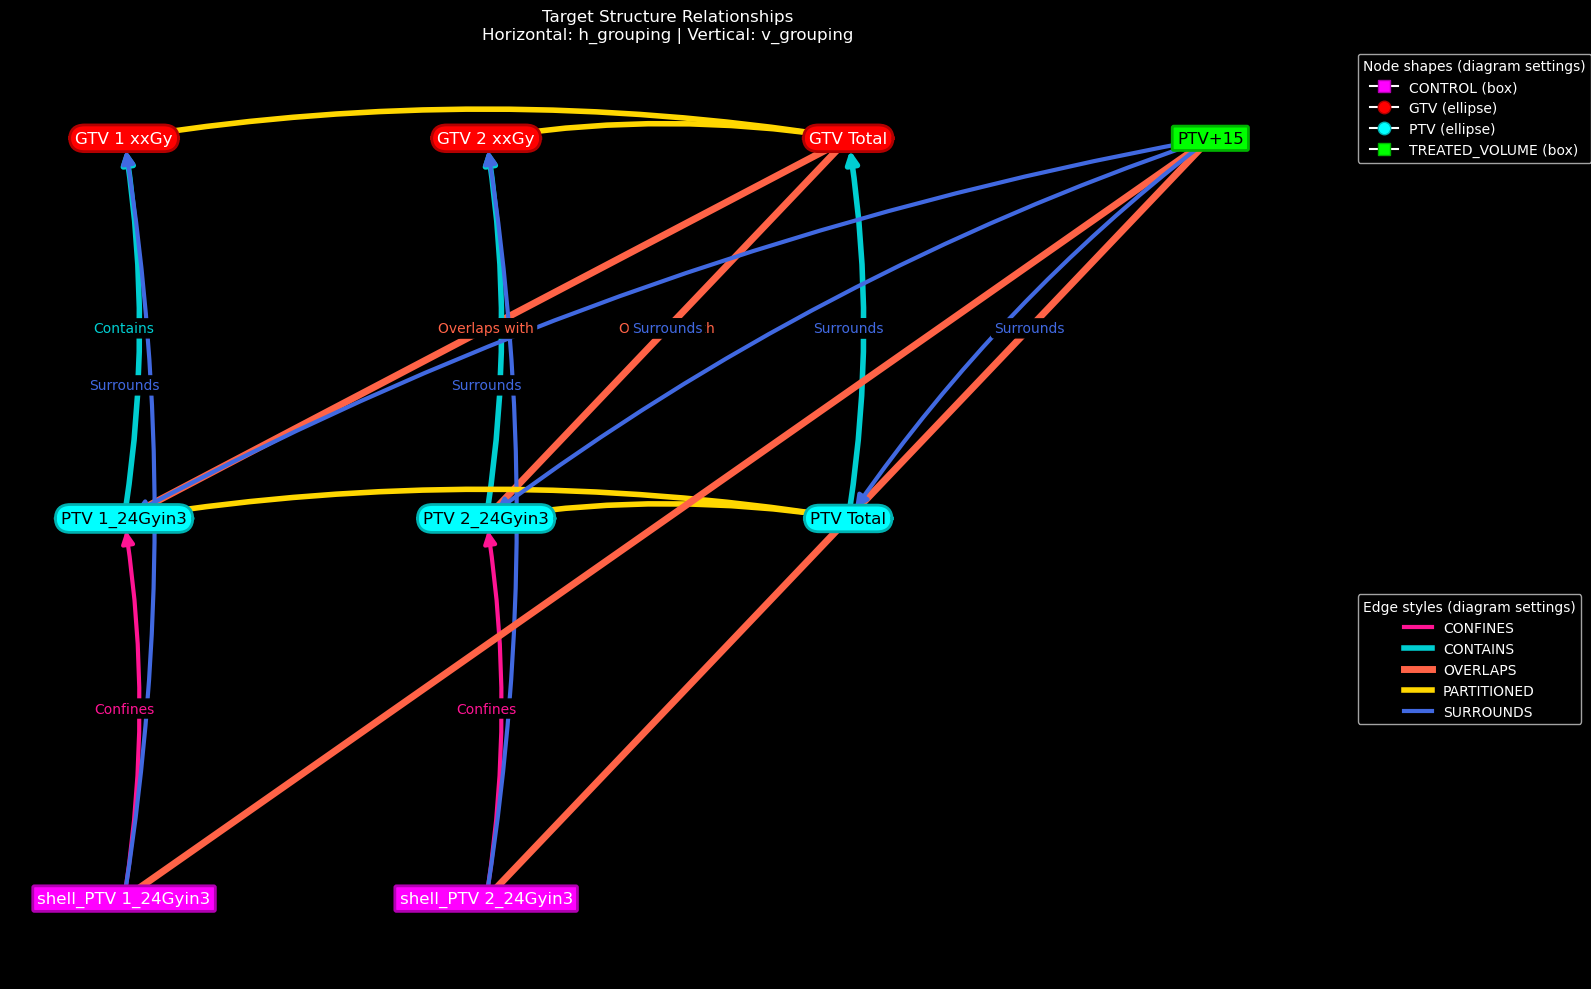

CONFINES       2
CONTAINS       3
OVERLAPS       4
PARTITIONED    4
SURROUNDS      5
dtype: int64

In [17]:
summary_df = structure_set.summary().copy()
node_color_map = get_node_color_map(structure_set, default_color=NODE_FILL_COLOR)

# Resolve the summary column name used for DICOM type.
dicom_type_summary_col = None
for candidate in ['DICOM Type', 'DICOM_Type']:
    if candidate in summary_df.columns:
        dicom_type_summary_col = candidate
        break

plot_nodes = summary_df[['ROI', 'Name']].copy()
plot_nodes['Name'] = plot_nodes['Name'].astype(str)
plot_nodes = plot_nodes.merge(
    structures_df[['h_grouping', 'v_grouping']],
    left_on='Name',
    right_index=True,
    how='left',
)

if dicom_type_summary_col is not None:
    plot_nodes['DICOM Type'] = summary_df[dicom_type_summary_col].astype(str)
elif 'DICOM Type' in structures_df.columns:
    plot_nodes = plot_nodes.merge(
        structures_df[['DICOM Type']],
        left_on='Name',
        right_index=True,
        how='left',
    )
    plot_nodes['DICOM Type'] = (
        plot_nodes['DICOM Type'].fillna('Unknown').astype(str)
    )
else:
    plot_nodes['DICOM Type'] = 'Unknown'

def _coerce_horizontal_group(raw_value):
    if pd.isna(raw_value):
        return 'missing'
    text_value = str(raw_value).strip()
    if text_value == '':
        return 'blank'

    lowered = text_value.lower()
    if lowered == 'none':
        return 'None'
    if lowered in {'(ungrouped)', 'ungrouped', 'missing'}:
        return 'missing'

    return text_value


def _is_numeric_group(group_value):
    try:
        float(str(group_value).strip())
        return True
    except (TypeError, ValueError):
        return False


def _horizontal_sort_key(group_value):
    if group_value == 'None':
        return (2, 0.0, '')
    if group_value == 'blank':
        return (3, 0.0, '')
    if group_value == 'missing':
        return (4, 0.0, '')
    if _is_numeric_group(group_value):
        return (0, float(str(group_value).strip()), '')
    return (1, 0.0, str(group_value).lower())


VERTICAL_ORDER = [
    'GTV',
    'CTV',
    'PTV',
    'TREATED VOLUME',
    'SHELL',
]
VERTICAL_ORDER_INDEX = {name: idx for idx, name in enumerate(VERTICAL_ORDER)}


def _vertical_order_name(group_value):
    upper_value = str(group_value).strip().upper().replace('_', ' ')
    if upper_value.startswith('GTV'):
        return 'GTV'
    if upper_value.startswith('CTV'):
        return 'CTV'
    if upper_value.startswith('PTV'):
        return 'PTV'
    if upper_value in {'TREATED VOLUME', 'TREATED_VOLUME'}:
        return 'TREATED VOLUME'
    if upper_value.startswith('SHELL'):
        return 'SHELL'
    return upper_value


def _vertical_sort_key(group_value):
    normalized = _vertical_order_name(group_value)
    return (VERTICAL_ORDER_INDEX.get(normalized, len(VERTICAL_ORDER)), normalized)


plot_nodes['h_grouping'] = plot_nodes['h_grouping'].apply(_coerce_horizontal_group)
plot_nodes['v_grouping'] = (
    plot_nodes['v_grouping'].fillna('(ungrouped)').astype(str)
)

h_order = sorted(
    plot_nodes['h_grouping'].unique(),
    key=_horizontal_sort_key,
)
h_index_map = {group_name: idx for idx, group_name in enumerate(h_order)}
plot_nodes['h_index'] = plot_nodes['h_grouping'].map(h_index_map)
plot_nodes['v_sort_key'] = plot_nodes['v_grouping'].map(_vertical_sort_key)

plot_nodes = plot_nodes.sort_values(
    by=['h_index', 'v_sort_key', 'Name', 'ROI']
).reset_index(drop=True)

vertical_index_map = {}
for h_group, group_rows in plot_nodes.groupby('h_grouping', sort=False):
    v_order = (
        group_rows[['v_grouping', 'v_sort_key']]
        .drop_duplicates()
        .sort_values(by='v_sort_key')
    )
    vertical_index_map[h_group] = {
        group_name: idx
        for idx, group_name in enumerate(v_order['v_grouping'].tolist())
    }

plot_nodes['v_index'] = plot_nodes.apply(
    lambda row: vertical_index_map[row['h_grouping']][row['v_grouping']],
    axis=1,
).astype(int)
plot_nodes['v_dup_index'] = plot_nodes.groupby(
    ['h_grouping', 'v_grouping']
).cumcount()
plot_nodes = plot_nodes.drop(columns=['v_sort_key'])

plot_nodes['vis_shape'] = plot_nodes['DICOM Type'].str.upper().map(shape_map)
plot_nodes['vis_shape'] = plot_nodes['vis_shape'].fillna(default_vis_shape)
plot_nodes['mpl_marker'] = plot_nodes['vis_shape'].map(vis_shape_to_marker)

roi_to_node_meta = {
    int(row['ROI']): row
    for _, row in plot_nodes.iterrows()
}
selected_rois = set(roi_to_node_meta.keys())

relationship_graph = nx.DiGraph()
for roi, row in roi_to_node_meta.items():
    node_color = node_color_map.get(int(roi), NODE_FILL_COLOR)
    relationship_graph.add_node(
        roi,
        label=row['Name'],
        dicom_type=row['DICOM Type'],
        vis_shape=row['vis_shape'],
        mpl_marker=row['mpl_marker'],
        node_color=node_color,
        node_border_color=darken_color(node_color),
        node_text_color=get_text_color(node_color),
        subset=int(row['h_index']),
        h_grouping=row['h_grouping'],
        v_grouping=row['v_grouping'],
        v_index=int(row['v_index']),
        v_dup_index=int(row['v_dup_index']),
    )

for source, target, edge_data in structure_set.relationship_graph.edges(data=True):
    if source not in selected_rois or target not in selected_rois:
        continue

    relationship = edge_data.get('relationship')
    if relationship is None:
        continue

    relation_type_obj = getattr(relationship, 'relationship_type', None)
    relation_type = (
        getattr(relation_type_obj, 'relation_type', None) or 'UNKNOWN'
    )

    if relation_type == 'DISJOINT' and not SHOW_DISJOINT:
        continue
    if relation_type == 'UNKNOWN' and not SHOW_UNKNOWN:
        continue
    if HIDE_LOGICAL_EDGES and bool(getattr(relationship, 'is_logical', False)):
        continue

    style = normalize_edge_style(relationship_styles_cfg.get(relation_type, {}))
    relation_label = getattr(relation_type_obj, 'label', relation_type)

    relationship_graph.add_edge(
        int(source),
        int(target),
        relation_type=relation_type,
        label=relation_label,
        color=style['color'],
        width=style['width'],
        dashes=style['dashes'],
        arrows=style['arrows'],
    )

if relationship_graph.number_of_nodes() == 0:
    raise ValueError('No nodes available for plotting')

# Tunable layout controls.
H_SPACING = 3.3
V_SPACING = 1.2
V_DUP_SPREAD = 0.35

_ = nx.multipartite_layout(
    relationship_graph,
    subset_key='subset',
    align='vertical',
    scale=1.0,
)

positions = {}
for roi, node_data in relationship_graph.nodes(data=True):
    x_coord = node_data['subset'] * H_SPACING
    y_coord = -(
        node_data['v_index'] * V_SPACING +
        node_data['v_dup_index'] * V_DUP_SPREAD
    )
    positions[roi] = (x_coord, y_coord)

fig, axis = plt.subplots(figsize=(16, 10))
axis.set_facecolor(figure_background)

for source, target, style_data in relationship_graph.edges(data=True):
    line_style = 'dashed' if style_data['dashes'] else 'solid'
    arrow_setting = style_data.get('arrows')

    edge_to_draw = (source, target)
    arrow_style = '-|>'
    draw_arrows = True

    if arrow_setting is None:
        draw_arrows = False
    elif arrow_setting == 'to;from':
        arrow_style = '<|-|>'
    elif arrow_setting == 'from':
        edge_to_draw = (target, source)

    edge_draw_kwargs = {
        'G': relationship_graph,
        'pos': positions,
        'edgelist': [edge_to_draw],
        'edge_color': style_data['color'],
        'width': style_data['width'],
        'style': line_style,
        'ax': axis,
    }

    if draw_arrows:
        edge_draw_kwargs.update({
            'arrows': True,
            'arrowstyle': arrow_style,
            'arrowsize': 18,
            'connectionstyle': 'arc3,rad=0.08',
        })
    else:
        edge_draw_kwargs.update({'arrows': False})

    nx.draw_networkx_edges(**edge_draw_kwargs)

for roi, node_data in relationship_graph.nodes(data=True):
    x_coord, y_coord = positions[roi]
    axis.text(
        x_coord,
        y_coord,
        node_data['label'],
        ha='center',
        va='center',
        fontsize=12,
        color=node_data['node_text_color'],
        bbox={
            'boxstyle': vis_shape_to_boxstyle(node_data['vis_shape']),
            'facecolor': node_data['node_color'],
            'edgecolor': node_data['node_border_color'],
            'linewidth': 2,
            'pad': 0.35,
        },
        zorder=6,
    )


def _rectangles_overlap(rect_a: tuple, rect_b: tuple) -> bool:
    ax0, ay0, ax1, ay1 = rect_a
    bx0, by0, bx1, by1 = rect_b
    return not (ax1 < bx0 or bx1 < ax0 or ay1 < by0 or by1 < ay0)


def _label_rect(center_x: float, center_y: float, label_text: str) -> tuple:
    width = max(0.92, 0.10 * len(label_text) + 0.32)
    height = 0.28
    return (
        center_x - width / 2,
        center_y - height / 2,
        center_x + width / 2,
        center_y + height / 2,
    )


def _node_rect(center_x: float, center_y: float, node_text: str) -> tuple:
    width = max(1.0, 0.12 * len(node_text) + 0.55)
    height = 0.42
    return (
        center_x - width / 2,
        center_y - height / 2,
        center_x + width / 2,
        center_y + height / 2,
    )


def _clamp(value: float, min_value: float, max_value: float) -> float:
    return max(min_value, min(max_value, value))


def _pick_label_position(
    source_point: tuple,
    target_point: tuple,
    label_text: str,
    node_rectangles: list,
    used_rectangles: list,
    bounds: tuple,
) -> tuple:
    source_x, source_y = source_point
    target_x, target_y = target_point

    delta_x = target_x - source_x
    delta_y = target_y - source_y
    length = (delta_x**2 + delta_y**2) ** 0.5
    if length < 1e-6:
        return source_x, source_y

    tangent_x = delta_x / length
    tangent_y = delta_y / length
    normal_x = -tangent_y
    normal_y = tangent_x

    mid_x = (source_x + target_x) / 2
    mid_y = (source_y + target_y) / 2

    # Keep labels close to their edge by default and resolve collisions by
    # sliding along the edge away from the midpoint.
    tangent_offsets = [0.0, 0.14, -0.14, 0.28, -0.28, 0.42, -0.42, 0.56, -0.56]

    min_x, max_x, min_y, max_y = bounds

    best_position = (mid_x, mid_y)
    best_score = float('inf')

    for tangent_offset in tangent_offsets:
        candidate_x = mid_x + tangent_offset * tangent_x
        candidate_y = mid_y + tangent_offset * tangent_y

        candidate_rect = _label_rect(candidate_x, candidate_y, label_text)

        overlap_penalty = 0
        for existing_rect in used_rectangles:
            if _rectangles_overlap(candidate_rect, existing_rect):
                overlap_penalty += 140

        node_penalty = 0
        for node_rect in node_rectangles:
            if _rectangles_overlap(candidate_rect, node_rect):
                node_penalty += 220

        out_of_bounds = (
            candidate_rect[0] < min_x or
            candidate_rect[2] > max_x or
            candidate_rect[1] < min_y or
            candidate_rect[3] > max_y
        )
        bounds_penalty = 240 if out_of_bounds else 0

        displacement_penalty = abs(tangent_offset) * 12
        total_score = (
            overlap_penalty +
            node_penalty +
            bounds_penalty +
            displacement_penalty
        )

        if total_score < best_score:
            best_score = total_score
            best_position = (candidate_x, candidate_y)

        if total_score < 1:
            return candidate_x, candidate_y

    clamped_x = _clamp(best_position[0], min_x + 0.15, max_x - 0.15)
    clamped_y = _clamp(best_position[1], min_y + 0.15, max_y - 0.15)
    return clamped_x, clamped_y


if SHOW_EDGE_LABELS and relationship_graph.number_of_edges() > 0:
    placed_label_rectangles = []

    all_x = [xy[0] for xy in positions.values()]
    all_y = [xy[1] for xy in positions.values()]
    label_bounds = (
        min(all_x) - 0.6,
        max(all_x) + 0.6,
        min(all_y) - 0.6,
        max(all_y) + 0.6,
    )

    node_rectangles = []
    for roi, node_data in relationship_graph.nodes(data=True):
        node_x, node_y = positions[roi]
        node_rectangles.append(_node_rect(node_x, node_y, node_data['label']))

    edge_items = list(relationship_graph.edges(data=True))
    edge_items.sort(
        key=lambda edge_tuple: (
            (positions[edge_tuple[0]][0] - positions[edge_tuple[1]][0])**2 +
            (positions[edge_tuple[0]][1] - positions[edge_tuple[1]][1])**2
        )
    )

    for source, target, style_data in edge_items:
        label_text = style_data['label']
        source_point = positions[source]
        target_point = positions[target]

        label_x, label_y = _pick_label_position(
            source_point,
            target_point,
            label_text,
            node_rectangles,
            placed_label_rectangles,
            label_bounds,
        )

        label_rectangle = _label_rect(label_x, label_y, label_text)
        if any(
            _rectangles_overlap(label_rectangle, node_rectangle)
            for node_rectangle in node_rectangles
        ):
            continue

        placed_label_rectangles.append(label_rectangle)

        axis.text(
            label_x,
            label_y,
            label_text,
            color=style_data['color'],
            fontsize=10,
            ha='center',
            va='center',
            bbox={
                'boxstyle': 'round,pad=0.18',
                'facecolor': figure_background,
                'edgecolor': figure_background,
                'linewidth': 1,
            },
            zorder=5,
        )

node_legend_handles = []
for dicom_type, type_rows in plot_nodes.groupby('DICOM Type'):
    vis_shape = type_rows['vis_shape'].iloc[0]
    sample_roi = int(type_rows['ROI'].iloc[0])
    sample_color = node_color_map.get(sample_roi, NODE_FILL_COLOR)
    node_legend_handles.append(
        Line2D(
            [0],
            [0],
            marker=vis_shape_to_marker(vis_shape),
            color='w',
            markerfacecolor=sample_color,
            markeredgecolor=darken_color(sample_color),
            markersize=9,
            label=f'{dicom_type} ({vis_shape})',
        )
    )

edge_legend_handles = []
present_relations = sorted(
    {
        style_data['relation_type']
        for _, _, style_data in relationship_graph.edges(data=True)
    }
)
for relation_name in present_relations:
    relation_style = normalize_edge_style(
        relationship_styles_cfg.get(relation_name, {})
    )
    edge_legend_handles.append(
        Line2D(
            [0],
            [0],
            color=relation_style['color'],
            linestyle='--' if relation_style['dashes'] else '-',
            linewidth=relation_style['width'],
            label=relation_name,
        )
    )

if node_legend_handles:
    node_legend = axis.legend(
        handles=node_legend_handles,
        title='Node shapes (diagram settings)',
        loc='upper left',
        bbox_to_anchor=(1.02, 1.0),
        frameon=True,
    )
    axis.add_artist(node_legend)

if edge_legend_handles:
    axis.legend(
        handles=edge_legend_handles,
        title='Edge styles (diagram settings)',
        loc='upper left',
        bbox_to_anchor=(1.02, 0.42),
        frameon=True,
    )

axis.set_title(
    'Target Structure Relationships\n'
    'Horizontal: h_grouping | Vertical: v_grouping'
)
axis.axis('off')
plt.tight_layout()
plt.show()

relationship_counts = Counter(
    style_data['relation_type']
    for _, _, style_data in relationship_graph.edges(data=True)
)
pd.Series(relationship_counts).sort_index()


In [18]:
structures_df[['h_grouping', 'v_grouping']]

,h_grouping,v_grouping
Structure,,
GTV 1 xxGy,1,GTV
PTV 1_24Gyin3,1,PTV
shell_PTV 1_24Gyin3,1,shell
GTV 2 xxGy,2,GTV
PTV 2_24Gyin3,2,PTV
shell_PTV 2_24Gyin3,2,shell
GTV Total,Total,GTV
PTV Total,Total,PTV
CTV,NaN,CTV
